In [1]:
import igl
import numpy as np
import scipy.sparse as sp
from scipy.sparse.linalg import eigsh
from scipy.sparse import diags
from src.fatemarkers import FateMarkers
from src import utils 

from meshplot import plot, subplot 
from matplotlib import pyplot as plt

import vtk 
import time 

In [25]:
import importlib

import src.meshharm 
import src.fatemarkers
importlib.reload(src.meshharm)
importlib.reload(src.fatemarkers)
from src.fatemarkers import FateMarkers

### Load data from precomputed values

In [ ]:
path = 'Data/20250818/fractal_output/day1p5/r0.zarr/A/01/0_fused_zillum_registered/fm_data/213'
m = FateMarkers()

# loads all the results inc fate markers 
m.load_results(path)

### Check reconstruction quality for a series of lmax values

maximumm l index: 15


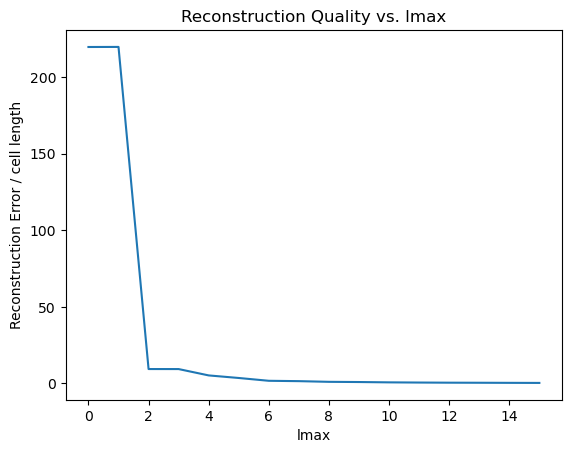

In [27]:
print('maximumm l index:', m.lmax)

errs = [] 
for l in range(m.lmax + 1):
    err = m.compute_recon_quality(lmax=l)
    errs.append(err)    

plt.plot(np.arange(len(errs)), errs)
plt.xlabel('lmax')
plt.ylabel('Reconstruction Error / cell length')
plt.title('Reconstruction Quality vs. lmax')
plt.show() 

### Compute HKS for a series of times (time ~ distance^2)

In [ ]:
ts = [1, 4, 25, 100]
hks = m.compute_hks_for_new_times(ts, coeffs=False)

print(hks.shape) # fields associated with each vertex 
print(m.v.shape) 

(44059, 4)
(44059, 3)


In [29]:
plot(m.v, m.f, c=hks[:, 0])

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.025527…

### Visualise the encoding using bag of features

In [ ]:
# loads the vocab from file 
res = np.load('sim/vocab.npz', allow_pickle=True)
vocab = res['vocab']
scaler = res['scalar'].item() 
sigma = res['sigma']
ts = res['ts']

hks = m.compute_hks_for_new_times(ts, coeffs=False)

In [32]:
hks_scaled = scaler.transform(hks)
dist = np.linalg.norm(hks_scaled[:, np.newaxis, :]- vocab[np.newaxis, :, :], axis=2)
encoding = np.exp(-dist**2 / (2 * sigma**2))

In [33]:
for i in range(encoding.shape[1]):
    print(np.min(encoding[:, i]), np.max(encoding[:, i]))
    plot(m.v, m.f, c=encoding[:, i])

0.0 0.0


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.025527…

2.9110467e-21 4.3969336e-15


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.025527…

0.0 0.0


...

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.025527…

0.13720736 0.8431555


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.025527…

0.0 0.0


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.025527…

### Visualise the reconstructed fate markers

In [41]:
recon_field = m.eigvecs[:, :int(m.lmax**2)] @ m.coeffs_fm[:int(m.lmax**2), ]

for (i, name) in enumerate(m.field_names):
    if i in [1, 2]:
        print(name)
        print(np.min(recon_field[:, i]), np.max(recon_field[:, i]))
        plot(m.v, m.f, c=recon_field[:, i])

4.C01.mean_intensity
5708.587718900119 7060.049317574544


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.025527…

4.C01.percentile95
11267.060049026195 13310.589545638873


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.025527…